# BencanaLens — Training Pipeline

Notebook ini mendokumentasikan pipeline training model MobileNetV2 untuk klasifikasi citra bencana.

**Paper:** "Klasifikasi Citra Bencana Alam Menggunakan Arsitektur MobileNetV2 melalui Transfer Learning Dua Fase dan Visualisasi Grad-CAM"

---

## 1. Setup & Import

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')


TensorFlow version: 2.15.0
GPU available: False


## 2. Konfigurasi

In [2]:
# Path dataset
DATA_DIR = Path('../data')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'
MODEL_SAVE_PATH = Path('../models/disaster_mobilenetv2_best.h5')

# Hyperparameter
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6
CLASS_NAMES = [
    'Damaged_Infrastructure',
    'Fire_Disaster',
    'Human_Damage',
    'Land_Disaster',
    'Non_Damage',
    'Water_Disaster',
]

# Fase 1
PHASE1_LR = 1e-3
PHASE1_EPOCHS = 30

# Fase 2
PHASE2_LR = 1e-5
PHASE2_EPOCHS = 30
UNFREEZE_LAYERS = 50  # jumlah layer terakhir yang dibuka

## 3. Data Generator

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Augmentasi untuk training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=True,
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=False,
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=False,
)

Found 9485 images belonging to 6 classes.
Found 2030 images belonging to 6 classes.
Found 2040 images belonging to 6 classes.


## 4. Bangun Model

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, Model

def build_model(num_classes=NUM_CLASSES):
    base = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
    )
    base.trainable = False  # Fase 1: freeze semua layer base

    inputs = base.input
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base

model, base_model = build_model()
model.summary()



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']      

## 5. Fase 1 — Feature Extraction

In [5]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE1_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_phase1 = [
    ModelCheckpoint(
        str(MODEL_SAVE_PATH), monitor='val_accuracy',
        save_best_only=True, verbose=1,
    ),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

history1 = model.fit(
    train_gen,
    epochs=PHASE1_EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
)
print(f'Fase 1 selesai. Val. Accuracy terbaik: {max(history1.history["val_accuracy"]):.4f}')

Epoch 1/30


297/297 [==============================] - ETA: 0s - loss: 0.6058 - accuracy: 0.8028
Epoch 1: val_accuracy improved from -inf to 0.88227, saving model to ..\models\disaster_mobilenetv2_best.h5


c:\Users\ACER\Documents\BencanaLens\disaster-classifier\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


297/297 [==============================] - 143s 475ms/step - loss: 0.6058 - accuracy: 0.8028 - val_loss: 0.3552 - val_accuracy: 0.8823 - lr: 0.0010
Epoch 2/30
297/297 [==============================] - ETA: 0s - loss: 0.3974 - accuracy: 0.8707
Epoch 2: val_accuracy improved from 0.88227 to 0.90148, saving model to ..\models\disaster_mobilenetv2_best.h5
297/297 [==============================] - 152s 513ms/step - loss: 0.3974 - accuracy: 0.8707 - val_loss: 0.3173 - val_accuracy: 0.9015 - lr: 0.0010
Epoch 3/30
297/297 [==============================] - ETA: 0s - loss: 0.3575 - accuracy: 0.8821
Epoch 3: val_accuracy did not improve from 0.90148
297/297 [==============================] - 144s 484ms/step - loss: 0.3575 - accuracy: 0.8821 - val_loss: 0.3350 - val_accuracy: 0.8842 - lr: 0.0010
Epoch 4/30
297/297 [==============================] - ETA: 0s - loss: 0.3226 - accuracy: 0.8947
Epoch 4: val_accuracy did not improve from 0.90148
297/297 [==============================] - 141s 475ms/s

## 6. Fase 2 — Fine-tuning

In [6]:
# Buka 50 layer terakhir base model
base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

print(f'Total layer trainable: {sum(1 for l in model.layers if l.trainable)}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_phase2 = [
    ModelCheckpoint(
        str(MODEL_SAVE_PATH), monitor='val_accuracy',
        save_best_only=True, verbose=1,
    ),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
]

history2 = model.fit(
    train_gen,
    epochs=PHASE2_EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
)
print(f'Fase 2 selesai. Val. Accuracy terbaik: {max(history2.history["val_accuracy"]):.4f}')

Total layer trainable: 56
Epoch 1/30
297/297 [==============================] - ETA: 0s - loss: 0.5657 - accuracy: 0.8180
Epoch 1: val_accuracy improved from -inf to 0.91429, saving model to ..\models\disaster_mobilenetv2_best.h5
297/297 [==============================] - 246s 817ms/step - loss: 0.5657 - accuracy: 0.8180 - val_loss: 0.2526 - val_accuracy: 0.9143 - lr: 1.0000e-05
Epoch 2/30
297/297 [==============================] - ETA: 0s - loss: 0.3540 - accuracy: 0.8867
Epoch 2: val_accuracy improved from 0.91429 to 0.91823, saving model to ..\models\disaster_mobilenetv2_best.h5
297/297 [==============================] - 231s 779ms/step - loss: 0.3540 - accuracy: 0.8867 - val_loss: 0.2365 - val_accuracy: 0.9182 - lr: 1.0000e-05
Epoch 3/30
297/297 [==============================] - ETA: 0s - loss: 0.3087 - accuracy: 0.9008
Epoch 3: val_accuracy improved from 0.91823 to 0.92414, saving model to ..\models\disaster_mobilenetv2_best.h5
297/297 [==============================] - 177s 595m

## 7. Evaluasi pada Test Set

64/64 [==============================] - 14s 208ms/step
                        precision    recall  f1-score   support

Damaged_Infrastructure       0.76      0.91      0.83       219
         Fire_Disaster       0.95      0.87      0.91       141
          Human_Damage       0.75      0.89      0.81        37
         Land_Disaster       0.77      0.62      0.69       100
            Non_Damage       0.99      0.98      0.99      1387
        Water_Disaster       0.82      0.79      0.80       156

              accuracy                           0.93      2040
             macro avg       0.84      0.84      0.84      2040
          weighted avg       0.94      0.93      0.93      2040



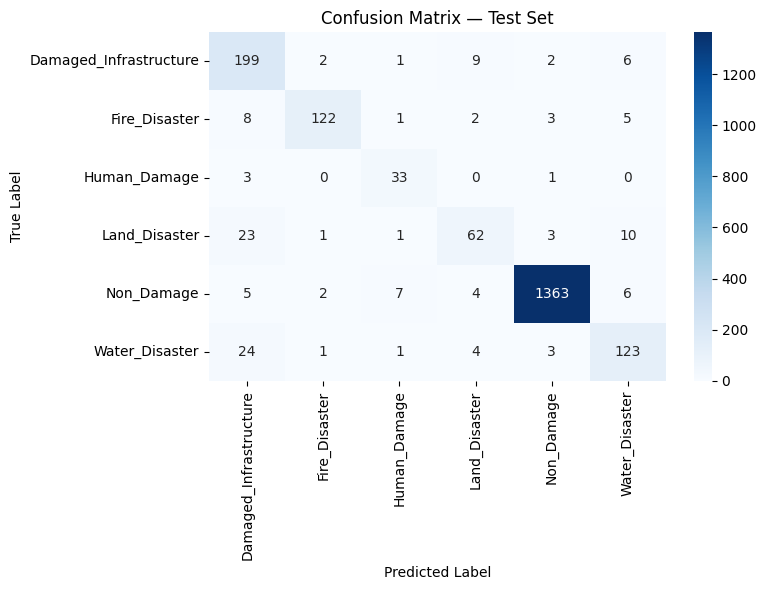

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load bobot terbaik
model.load_weights(str(MODEL_SAVE_PATH))

# Prediksi
test_gen.reset()
preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

# Classification report
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 8. Visualisasi Kurva Training


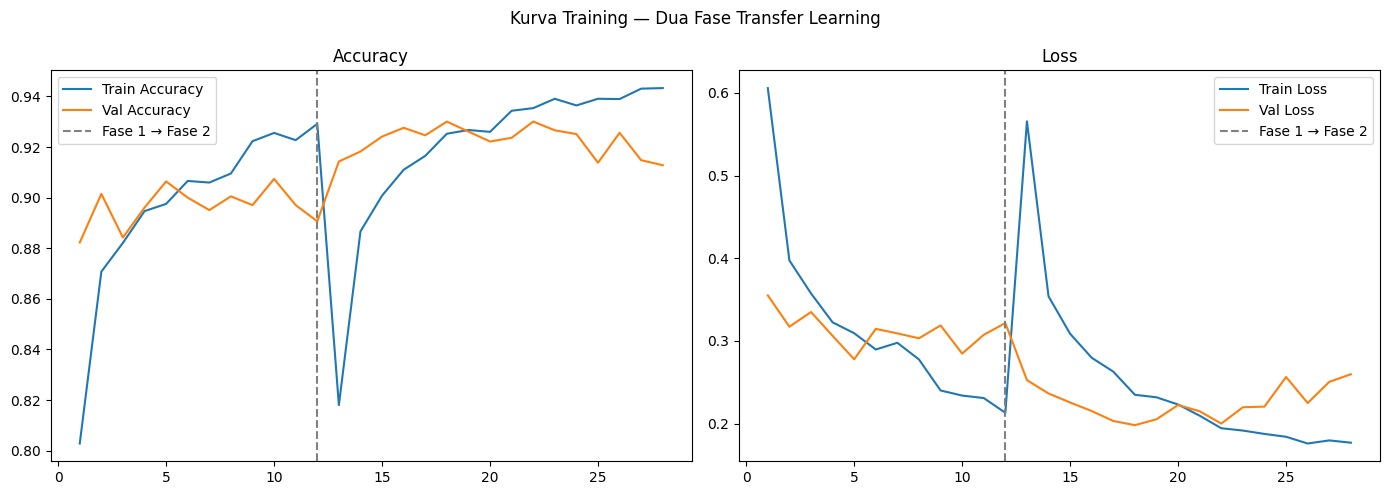

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gabungkan history dua fase
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
phase1_end = len(history1.history['accuracy'])

epochs_range = range(1, len(acc) + 1)

axes[0].plot(epochs_range, acc, label='Train Accuracy')
axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
axes[0].axvline(x=phase1_end, color='gray', linestyle='--', label='Fase 1 → Fase 2')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(epochs_range, loss, label='Train Loss')
axes[1].plot(epochs_range, val_loss, label='Val Loss')
axes[1].axvline(x=phase1_end, color='gray', linestyle='--', label='Fase 1 → Fase 2')
axes[1].set_title('Loss')
axes[1].legend()

plt.suptitle('Kurva Training — Dua Fase Transfer Learning')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()